# TẦNG 4 (VER 2) — KẾ HOẠCH SỬA: KIỂM MỘC TRÊN VÙNG KÝ ĐỘNG
## Phạm vi ver2: **CHỈ `LOADING_PLAN`** (số ảnh đếm động ở Cell 3). `HOA_DON` đã gỡ khỏi phạm vi 27/09 — mỗi chi nhánh cần template riêng.
## KHÔNG viết lại Tầng 4 từ đầu. KHÔNG đụng PO / PGH / PXK / BBBG ở vòng này.

---

## 0. Kết luận rà soát (đọc trước khi code)

| Ý định | Đánh giá | Lý do |
|---|---|---|
| Đóng băng template, chưa làm PO | ✅ GIỮ | Chỉ `LOADING_PLAN` có zone động; PO chưa có zone động thì web sẽ vẽ khung sai |
| Chạy `HOA_DON` bằng một resolver chung | ⏸️ **HOÃN** (27/09) | Mỗi chi nhánh/kênh là một biểu mẫu khác → cần template riêng. Mọi ảnh `HOA_DON` ABSTAIN |
| Làm Tầng 4 kiểm mộc rồi mới web | ✅ GIỮ thứ tự | Web cần API `verdict + crop + lý do`, không cần phủ mọi template |
| Viết Tầng 4 mộc mới từ đầu | ❌ BỎ | `ocr-tang4-verify.ipynb` + `tools/stage4_verifier.py` đã có Engine A/B. Tầng 3 ver 2 **đã gọi** `verify_single_target` cho cả chữ ký lẫn mộc |
| Cắm web vào Tầng 4 cũ như hiện tại | ❌ CẤM | Tầng 4 cũ đọc BBox hardcode từ `stage3_batched_manifest.json`. Tầng 3 ver 2 đã chứng minh BBox đó đè bảng kem (Trang 1) và rơi giấy trắng Y=0.62 (Trang 2) |
| Bỏ Tầng 3 batch (`ocr-tang3-batch.ipynb`) | ❌ CẤM | Web cần **lô chuyến xe**. Tầng 3 ver 2 chỉ sửa **hình học vùng ký**, không thay gom lô |
| Chạy Tầng 4 trên ảnh chưa chuẩn hóa zone | ❌ CẤM | Abstain `CHUA_CHUAN_HOA_VUNG_KY`, không đoán |

**Tách tầng đúng cho web (đóng băng tên, đừng đổi nữa):**
```text
Tầng 1  Chuẩn hóa ảnh          → output/stage1_out/
Tầng 2  Phân loại + key field  → output/stage2_out/stage2_classified_results.json
Tầng 3  Gom lô chuyến xe       → output/stage3_out/stage3_batched_manifest.json
Tầng 3b Zone động theo template → detect_loading_plan_signature_zone   (HOA_DON: HOÃN)
Tầng 4  Kiểm CHỮ KÝ + MỘC trên zone động → output/stage4_out/
```
**Hợp đồng ABSTAIN (Giai đoạn 1a, 27/09):** Tầng 3b trả `has_signatures=False` mà không phải
`PAGE_1_NO_SIGNATURES` (vd. `COLUMN_DETECTION_FAILED`, `COLUMN_ORDER_VIOLATION`, `COLUMN_PITCH_IMPLAUSIBLE`,
`COLUMN_OCR_UNAVAILABLE`, `COLUMN_LABELS_UNAVAILABLE`, hoặc status mới bất kỳ) hay `targets == []`
⇒ `CHUA_CHUAN_HOA_VUNG_KY / ABSTAIN`, giữ nguyên `zone_status` + lý do. **Không bao giờ** phán `CHUA_KY_DONG_DAU`
từ một tập vị trí rỗng.
Tầng 4 **không** tự dò lại đáy bảng. Tầng 4 **nhận** `targets[]` (đã có `box_norm`, `role`, `expected_color`, `required`, `stamp_shape`) rồi trả `detected / ink_type / confidence / reason`.

---

## 1. Tám chỗ phải sửa trong Tầng 4 cũ (map 1-1 sang code)

### SỬA 1 — Nguồn BBox: bỏ manifest hardcode, lấy zone động

**Sai (Cell 3 + Cell 9 Tầng 4 cũ):**
```python
MANIFEST_PATH = "output/stage3_out/stage3_batched_manifest.json"
targets = doc.get("signature_targets", [])   # BBox cứng Y=0.62 / Y=0.78
```

**Đúng:**
```python
from tools.stage2_classifier import *  # chỉ để đọc JSON Tầng 2
from tools.kido_pipeline import detect_loading_plan_signature_zone
from tools.stage4_verifier import detect_document_modality
from tools.stage4_verifier_v2 import evaluate_document_verdict_v2   # hiểu required=False; 0 required ⇒ ABSTAIN

# Ảnh vào Tầng 4 bắt buộc đã scale H=2200 (cùng contract Tầng 3 ver 2)
scale = 2200.0 / raw.shape[0]
a4 = cv2.resize(raw, (int(raw.shape[1] * scale), 2200))

s2 = s2_map[fn]
if s2["doc_type"] == "LOADING_PLAN":
    zone = detect_loading_plan_signature_zone(a4, page_role=s2.get("page_role", "HEADER"))
else:
    zone = {"status": "CHUA_CHUAN_HOA_VUNG_KY", "has_signatures": False, "targets": []}
```
Nếu `zone["status"] == "PAGE_1_NO_SIGNATURES"` → không gọi verifier, verdict = `TRANG_1_CHUA_KY` (HỢP LỆ).
Nếu `has_signatures == False` (mọi status khác) hoặc `targets == []` → abstain `CHUA_CHUAN_HOA_VUNG_KY`, giữ `zone_status`, không fallback BBox cứng.

---

### SỬA 2 — extract_adaptive_roi: cấm margin 15% liếm lề
- **Sai:** `ADAPTIVE_MARGIN = 0.15` rồi `x1 = (xmin - 0.15*box_w)*w` → với xmin=0.05 sẽ chạm X=0, Engine B nhận nhầm vạch đen máy photo thành chữ ký/mộc (`Hoadon_2.1__0`, `Hoadon3.11__0`).
- **Đúng — clamp cứng theo Tầng 3 ver 2:**
```python
SAFE_X = (0.08, 0.96)   # hóa đơn cột trái: xmax <= 0.44 đã được zone resolver set
SAFE_Y = (0.02, 0.97)
STAMP_MARGIN = 0.08     # mộc tròn/vuông được nới ÍT hơn chữ ký
SIG_MARGIN   = 0.12

def extract_safe_roi(img, box_norm, margin, safe_x=SAFE_X, safe_y=SAFE_Y):
    h, w = img.shape[:2]
    ymin, xmin, ymax, xmax = box_norm
    bh, bw = ymax - ymin, xmax - xmin
    y1 = int(max(safe_y[0], ymin - margin * bh) * h)
    y2 = int(min(safe_y[1], ymax + margin * bh) * h)
    x1 = int(max(safe_x[0], xmin - margin * bw) * w)
    x2 = int(min(safe_x[1], xmax + margin * bw) * w)
    y1, x1 = max(0, y1), max(0, x1)
    y2, x2 = min(h, y2), min(w, x2)
    if y2 - y1 < 8 or x2 - x1 < 8:
        return None, (y1, x1, y2, x2)
    return img[y1:y2, x1:x2], (y1, x1, y2, x2)
```
Xóa mọi BBox hardcode trong case study:
- `[0.606, 0.317, 0.796, 0.549]` (Cell 13–14 Tầng 4 cũ)
- `LEGACY_LOADING_PLAN_PRESET` Y=0.62
- `LEGACY_INVOICE_PRESET` Y=0.78–0.95
Case study chỉ lấy `zone["targets"]`.

---

### SỬA 3 — Engine A mộc: cấm đếm pixel. Phải có HÌNH HỌC mộc
> ⏸️ Các ví dụ `HOA_DON` trong SỬA 3 và SỬA 6 là **tài liệu thiết kế cho template hóa đơn — HOÃN**, không chạy ở vòng này.
- **Sai:**
```python
if red_px > 60: detected = True          # 60 px = nhiễu / chữ đỏ in sẵn
elif blue_px > 100: detected = True      # chữ ký xanh bị nhận là mộc đỏ công ty
```
Hậu quả: logo KIDO đỏ, tiêu đề đỏ, dòng FPT chân trang, chữ ký xanh trong cùng ROI → DAT ảo.
- **Đúng — tách 2 class mộc, bắt buộc qua cổng hình học:**
```python
STAMP_CLASS = {
    "COMPANY_ROUND_RED": {   # mộc pháp nhân KIDO trên Hóa đơn / PXK
        "hsv": [([0, 50, 40], [14, 255, 255]), ([165, 50, 40], [180, 255, 255])],
        "shape": "circle",          # HoughCircles HOẶC contour circularity >= 0.65
        "min_diameter_ratio": 0.22, # so với min(w,h) của ROI
        "max_diameter_ratio": 0.95,
        "min_ink_px": 400,          # trên ảnh H=2200, ROI mộc ~180–280 px
        "allow_blue_purple": False, # CẤM nhận chữ ký xanh là mộc đỏ
    },
    "SUPERMARKET_SQUARE": {  # Co.op / GS25 CJ / Satra / BigC / BHX
        "hsv": [
            ([0, 50, 40], [14, 255, 255]),
            ([165, 50, 40], [180, 255, 255]),
            ([90, 40, 40], [145, 255, 255]),   # xanh
            ([130, 40, 40], [165, 255, 255]),  # tím
        ],
        "shape": "rect",            # minAreaRect, 0.55 <= w/h <= 1.80
        "min_side_ratio": 0.25,
        "min_ink_px": 350,
        "allow_blue_purple": True,
        "need_closed_border": True, # viền khung khép (morph gradient)
    },
}

def circularity(cnt):
    a = cv2.contourArea(cnt)
    p = cv2.arcLength(cnt, True)
    return 0.0 if p < 1 else 4 * np.pi * a / (p * p)

def verify_stamp_color(crop, stamp_class):
    # 1) mask màu theo class
    # 2) morph close 5x5 → contours
    # 3) cổng HÌNH: circle | rect
    # 4) cổng DIỆN TÍCH + đường kính
    # 5) reject nếu chỉ là blob nhỏ / chữ in / vệt lề
    # Trả detected chỉ khi VƯỢT CẢ 3 cổng (màu + hình + diện tích)
```
Gán `stamp_class` ngay trong zone resolver (Tầng 3b), không suy từ role.lower() chứa chữ "siêu thị":
- `HOA_DON` + role chứa "Con dấu mộc đỏ" / "Người bán" overlap mộc → `COMPANY_ROUND_RED`
- `HOA_DON` + system ∈ `{MT_COOP, MT_GS25, MT_SATRA, MT_BIGC, MT_BHX}` + role mộc tiếp nhận → `SUPERMARKET_SQUARE`
- `LOADING_PLAN` → không có target mộc đỏ công ty. Đừng bịa thêm.

---

### SỬA 4 — Engine B photocopy: cấm max_area > 350 ⇒ mộc
- **Sai:**
```python
if stamp_components > 0 or max_area > 350 or total_stroke_area > 500:
    detected = True
    ink_type = "bw_stamp_border"
```
Trên bản photo, đường kẻ bảng / khối chữ in / vệt lề đều > 350 px → False Accept hàng loạt.
- **Đúng — photo mộc chỉ đạt khi có VIỀN KHÉP:**
```python
def verify_stamp_bw(crop, stamp_class):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    # không dùng threshold diện tích thô
    edges = cv2.Canny(gray, 40, 120)
    # vòng tròn: HoughCircles (minR/maxR theo ROI)
    # vuông: findContours trên morph gradient, approxPolyDP 4 đỉnh, độ đặc > 0.7
    # connected component bên TRONG viền phải có "mực" (chữ trong mộc), không phải khung rỗng in sẵn
    # reject component cao < 22px (font in '(Ký, ghi rõ họ tên)')
```
Photocopy đạt mộc → `DAT_CHUAN_PHOTO`. Không bao giờ gắn `DAT_CHUAN_GOC` cho `PHOTOCOPY_BW` (SOP KIDO: nghiệm thu gốc phải có mộc đỏ sống — giữ nguyên luật này, chỉ ghi chú trên UI web).

---

### SỬA 5 — Cấm fallback BW khi đang kiểm MỘC ĐỎ trên tài liệu MÀU
- **Sai (Cell 8 Tầng 4 cũ):**
```python
if is_color:
    res = verify_color_roi(...)
    if not res["detected"]:
        bw_res = verify_bw_roi(...)   # bảng kẻ / chữ in → "black_ink_on_color_doc" = ĐẠT ẢO
```
Fallback BW chỉ hợp lệ với chữ ký (bút đen trên scan màu). Với mộc đỏ pháp nhân trên tài liệu `TRUE_COLOR`: không có đỏ → THIẾU MỘC. Không được cứu bằng viền đen.
```python
def verify_single_target(img, target, is_color=True):
    is_stamp = target.get("expected_color") in ("red_stamp", "any_stamp") or target.get("stamp_class")
    margin = STAMP_MARGIN if is_stamp else SIG_MARGIN
    crop, bbox = extract_safe_roi(img, target["box_norm"], margin)
    ...
```

---

### SỬA 6 — Verdict phải tôn trọng required=False (WinMart Row 33)
- **Sai:**
```python
req_count = len(targets)          # đếm cả ô miễn trừ
det_count = sum(vt["detected"] for vt in verified_targets)
if det_count == req_count: DAT_CHUAN_...
```
WinMart (`Hoadon_3.6__0`, `Hoadon2.2__2`) sẽ `THIEU_MOT_SO_CHU_KY` oan vì người mua không ký trên HĐ.
- **Đúng — bắt buộc dùng evaluate_document_verdict của Tầng 3 ver 2:**
```python
v = evaluate_document_verdict(
    target_results,
    mapping_status=zone["status"],
    doc_type=s2["doc_type"],
)
# Chỉ đếm target required=True
# Optional miss → không hạ DAT
# PAGE_1_NO_SIGNATURES → TRANG_1_CHUA_KY (HỢP LỆ)
```

**Ma trận SOP khóa cứng (không suy diễn):**

| system | Người mua | Mộc vuông ST | Mộc đỏ / ký số KIDO |
|---|---|---|---|
| MT_COOP / MT_GS25 / MT_SATRA / MT_BIGC | required | required `SUPERMARKET_SQUARE` | required `COMPANY_ROUND_RED` |
| MT_WINMART | required=False | không có | required |
| MT_AEON / MT_LOTTE / MT_EMART | required | không có | required |
| MT_BHX | miễn trừ trên HĐ | required (thủ kho DC) | required |
| GT | required (Đại diện NPP) | không có | required |

---

### SỬA 7 — Phạm vi chạy + hợp đồng abstain cho web
Chỉ duyệt file có `doc_type ∈ {LOADING_PLAN}`.
Mọi ảnh còn lại (HOA_DON — HOÃN, PO, PGH, PXK, BBBG, Lệnh điều xe, nhiệt độ, thu hồi, nợ/trả…; số lượng đếm động ở Cell 3):
```json
{
  "doc_status": "CHUA_CHUAN_HOA_VUNG_KY",
  "action": "ABSTAIN",
  "reason": "Template chưa có zone động Tầng 3b — không chạy Tầng 4"
}
```
Web MVP filter doc_type `LOADING_PLAN`. Nút "xem PO" chỉ hiện badge chưa chuẩn hóa, không vẽ BBox giả.
Tầng 3 batch vẫn nạp để group theo `batch_id` / kênh trên UI. Tầng 4 chỉ ghi đè `verification_summary` của các trang `LOADING_PLAN` có zone hợp lệ.

---

### SỬA 8 — Contract JSON Tầng 4 (web đọc đúng 1 file)
Xuất `output/stage4_out/stage4_verification_manifest_v2.json`:
```json
{
  "version": "2.0.0-stamp-geometry",
  "scope": ["LOADING_PLAN"],
  "n_documents_in_scope": 19,
  "n_documents_abstain": 53,
  "documents": [
    {
      "file_name": "Loadingplan_5.1__0.png",
      "doc_type": "LOADING_PLAN",
      "system": "INTERNAL_TRANSFER",
      "page_role": "HEADER",
      "modality": "PHOTOCOPY_BW",
      "zone_status": "FLOATING_BELOW_TABLE",
      "anchor_y": 0.56,
      "doc_status": "DAT_CHUAN_PHOTO",
      "required_targets": 3,
      "detected_required_targets": 3,
      "targets": [
        {
          "role": "Mộc tiếp nhận siêu thị",
          "stamp_class": "SUPERMARKET_SQUARE",
          "expected_color": "any_stamp",
          "required": true,
          "box_norm": [0.56, 0.10, 0.70, 0.42],
          "bbox_px": [1232, 160, 1540, 672],
          "detected": true,
          "confidence": 0.88,
          "ink_type": "bw_square_border",
          "reason": "viền chữ nhật khép, aspect=1.21, ink_px=2140"
        }
      ]
    }
  ]
}
```
Cấm serialize `red_mask` / `fg_mask` numpy vào JSON.
CSV kế toán: 1 dòng / target, cột `required`, `stamp_class`, `reason`, `abstain`.

---

## 2. Bộ nghiệm thu bắt buộc — CHỈ `LOADING_PLAN` (viết lại 27/09, Giai đoạn 1a)

Bảng 8 ca cũ (6 ca `HOA_DON` + 2 ca `Load_3.5`) **đã gỡ**: `HOA_DON` HOÃN, còn ca `Load_3.5__0 → DAT_CHUAN_GOC`
là kỳ vọng mù (lúc đó Tầng 3b ABSTAIN trang này; từ Giai đoạn 4 hình học per-column dựng được 5 ô, nhãn đo ở GT production v4,
không phải ở bảng nghiệm thu này).
Bảng mới **xây từ trạng thái thật của Tầng 3b** trên ảnh Tầng 1 H=2200 (chính đường runner), kỳ vọng độc lập duy nhất
lấy từ GT người gán `output/stage4_dynamic_gt/gt_labeled.json` (trang `NO_SIGNATURE_BLOCK`):

| # | Kiểm tra | Kỳ vọng |
|---|---|---|
| A | Mọi file Tầng 2 có bản ghi trong `res_map` | thiếu ⇒ FAIL tường minh, không `KeyError` |
| B | Trang GT gán `NO_SIGNATURE_BLOCK` | zone `PAGE_1_NO_SIGNATURES` ⇒ `TRANG_1_CHUA_KY / HOP_LE`, 0 target |
| C | Mọi trang `PAGE_1_NO_SIGNATURES` | `TRANG_1_CHUA_KY / HOP_LE`, 0 target |
| D | Mọi trang zone ABSTAIN (`has_signatures=False` khác PAGE_1, hoặc `targets == []`) | `CHUA_CHUAN_HOA_VUNG_KY / ABSTAIN`, giữ `zone_status` |
| E | Trang có target | verdict nhất quán với số required phát hiện được; không bao giờ `CHUA_KY_DONG_DAU` khi 0 required; có target required `review_required` (ảnh BW `BW_*_UNVALIDATED`, `STAMP_CLASS_UNRESOLVED`) ⇒ `CAN_KIEM_TRA_TAY / REVIEW_REQUIRED`, không bao giờ `CHUA_KY_DONG_DAU` / `DAT_*` |
| F | Cổng âm 1 | Không target `COMPANY_ROUND_RED` nào `detected=True` chỉ vì mực xanh |
| G | Cổng âm 2 | Không file `doc_type ∉ {LOADING_PLAN}` (kể cả `HOA_DON`) có phán quyết khác `CHUA_CHUAN_HOA_VUNG_KY / ABSTAIN` |

**Cố ý KHÔNG có ca kỳ vọng `DAT_CHUAN_GOC`** ở bảng này — độ chính xác detector đo bằng GT production
(`tools/bench_lp_prod.py`), không đo ở đây. Bản engine cũ trên H=2200 cho TN≈0; engine chữ ký Giai đoạn 4 (box chặt + dải biên,
ngưỡng mm²) đo lại trên GT production. **CHECK cảnh báo TN=0 vẫn giữ và đo thật mỗi lần chạy**: nếu mọi ô được kiểm đều
`detected=True` ⇒ ghi `V2_SIGNATURE_TN_ZERO` vào `known_issues`; nếu TN>0 thì `known_issues` không được chứa mã đó (check H).

---

## 3. Việc KHÔNG làm ở vòng này

- Không viết detector mộc cho PO / PGH / PXK / BBBG / Lệnh điều xe.
- Không train model, không YOLO, không SAM. Rule-based HSV + Hough/contour trên ROI đã neo.
- Không nhị phân hóa ảnh gốc (giữ 3 kênh — Tầng 1 đã cam kết).
- Không `%matplotlib inline`.
- Không `fn.startswith("Load_")` / regex tên file. Zone chỉ nhận `doc_type`, `page_role`, `system` từ Tầng 2.
- Không đổi `evaluate_document_verdict` theo hướng "đếm mọi target".
- Không serve web cho đến khi bảng nghiệm thu mục 2 PASS **và** TN=0 đã được đo lại trên GT động.

---

## 4. Thứ tự cell notebook `ocr-tang4-stamp-ver2.ipynb`

1. **Cell 0 (Markdown):** Chính toàn bộ nội dung kế hoạch sửa này.
2. **Cell 1 (Code):** Import + nạp `stage2_classified_results.json` + `stage3_batched_manifest.json` (chỉ để lấy `batch_id`).
3. **Cell 2 (Code):** Patch `extract_safe_roi` + `verify_stamp_color` + `verify_stamp_bw` + `verify_single_target` (Sửa 2–5).
4. **Cell 3 (Code):** Runner toàn bộ ảnh Tầng 2: `LOADING_PLAN` in-scope, còn lại ABSTAIN (Sửa 1, 6, 7) — số lượng đếm động.
4b. **Cell 3b (Code):** Phán quyết HỒ SƠ đa trang `LOADING_PLAN` — nhóm trang lấy từ Tầng 3 (`documents[].page_files`), required theo kênh (`config/stage4_lp_required_policy.json`, nguồn SOP sheet Guideline).
5. **Cell 4 (Code):** Bảng nghiệm thu `LOADING_PLAN` (mục 2) — assert + CHECK cảnh báo TN=0 + check P (chính sách kênh) / I (hồ sơ đa trang).
6. **Cell 5 (Code):** Visual Crop inspector: 1 hàng = 1 target trên trang `LOADING_PLAN` có zone (ảnh ROI \| mask \| verdict).
7. **Cell 6 (Code):** Xuất JSON/CSV contract (`stage4_verification_manifest_v2.json` và `stage4_audit_summary_v2.csv`).

In [1]:
# CELL 1: IMPORT THƯ VIỆN & NẠP METADATA TẦNG 2 / TẦNG 3
import os
import sys
sys.path.insert(0, ".")
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')
import json
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# HOA_DON = HOÃN (27/09): không import detect_invoice_signature_zone — phạm vi chỉ LOADING_PLAN.
from tools.kido_pipeline import detect_loading_plan_signature_zone
from tools.stage4_verifier import detect_document_modality
# Giai đoạn 5 (27/09): chính sách vai trò ký bắt buộc LOADING_PLAN theo kênh — nguồn SOP sheet
# Guideline, luật nằm trong config/stage4_lp_required_policy.json. Thiếu/hỏng config ⇒ Stage4PolicyError
# ngay tại đây (không có dự phòng hardcode).
from tools.stage4_required_policy import (
    load_lp_required_policy, apply_lp_required_policy, policy_summary, evaluate_lp_dossier_verdicts,
)
LP_POLICY = load_lp_required_policy()
print(f"Chính sách required LOADING_PLAN: {LP_POLICY['_path']} v{LP_POLICY.get('version')} — "
      f"kênh {sorted(LP_POLICY['channels'])}")

# Ghi mtime của resolver Tầng 3b lúc chạy: module này đang được sửa song song,
# kết quả zone có thể đổi giữa các lần chạy — manifest phải truy được về bản nào.
import datetime as _dt
STAGE3B_RESOLVER_PATH = "tools/stage3b_zone_resolver.py"
STAGE3B_RESOLVER_MTIME = (
    _dt.datetime.fromtimestamp(os.path.getmtime(STAGE3B_RESOLVER_PATH)).isoformat(timespec="seconds")
    if os.path.exists(STAGE3B_RESOLVER_PATH) else None
)
print(f"Tầng 3b resolver: {STAGE3B_RESOLVER_PATH} (mtime {STAGE3B_RESOLVER_MTIME})")

STAGE1_DIR = "output/stage1_out/images/form_samples"
STAGE1_ALT = "output/form_samples"
STAGE2_PATH = "output/stage2_out/stage2_classified_results.json"
STAGE3_PATH = "output/stage3_out/stage3_batched_manifest.json"

def get_image_path(fn):
    p1 = os.path.join(STAGE1_DIR, fn)
    if os.path.exists(p1): return p1
    p2 = os.path.join(STAGE1_ALT, fn)
    if os.path.exists(p2): return p2
    return None

# Nạp metadata Tầng 2
with open(STAGE2_PATH, "r", encoding="utf-8") as f:
    s2_data = json.load(f)
s2_map = {item["file_name"]: item for item in s2_data}

# Nạp Tầng 3 chỉ để lấy batch_id và channel context
doc_batch_map = {}
if os.path.exists(STAGE3_PATH):
    with open(STAGE3_PATH, "r", encoding="utf-8") as f:
        s3_manifest = json.load(f)
    for b in s3_manifest.get("batches", []):
        bid = b.get("batch_id", "UNKNOWN_BATCH")
        for doc in b.get("documents", []):
            fn = doc.get("file_name")
            if fn: doc_batch_map[fn] = bid
            for pf in doc.get("page_files", []):
                doc_batch_map[pf] = bid

print(f"✅ Đã nạp thành công:")
print(f"   - Tầng 2 metadata: {len(s2_map)} tài liệu")
print(f"   - Tầng 3 batch map: {len(doc_batch_map)} file đã ánh xạ vào Lô chuyến xe")

Chính sách required LOADING_PLAN: D:\OCR_chuki\config\stage4_lp_required_policy.json v1.0.0 — kênh ['KHO_NOIBO', 'KHO_THUE', 'MT', 'NPP', 'UNRESOLVED']
Tầng 3b resolver: tools/stage3b_zone_resolver.py (mtime 2026-09-29T00:35:03)
✅ Đã nạp thành công:
   - Tầng 2 metadata: 72 tài liệu
   - Tầng 3 batch map: 137 file đã ánh xạ vào Lô chuyến xe


In [2]:
# CELL 2: BỘ ENGINE MỘC & CHỮ KÝ CHUẨN HÌNH HỌC (SỬA 2, 3, 4, 5)
# NGUỒN SỰ THẬT DUY NHẤT: tools/stage4_verifier_v2.py
# (trước đây engine được nhúng dưới dạng chuỗi trong generate_nb4_ver2.py —
#  nay đã tách thành module thật, notebook và web/API dùng chung một bản code)
from tools.stage4_verifier_v2 import (
    SAFE_X,
    SAFE_Y,
    STAMP_MARGIN,
    SIG_MARGIN,
    STAMP_CLASS,
    REVIEW_REQUIRED_EVIDENCE,
    extract_safe_roi,
    circularity,
    resolve_stamp_class,
    verify_stamp_color,
    verify_stamp_bw,
    verify_signature,
    verify_single_target,
    evaluate_document_verdict_v2,
)

print("✅ Đã nạp Bộ Engine Mộc & Chữ Ký Chuẩn Hình Học từ tools/stage4_verifier_v2.py (SỬA 2–5)")
print(f"   - SAFE_X={SAFE_X}, SAFE_Y={SAFE_Y}, STAMP_MARGIN={STAMP_MARGIN}, SIG_MARGIN={SIG_MARGIN}")
print(f"   - Lớp mộc hỗ trợ: {list(STAMP_CLASS.keys())}")

✅ Đã nạp Bộ Engine Mộc & Chữ Ký Chuẩn Hình Học từ tools/stage4_verifier_v2.py (SỬA 2–5)
   - SAFE_X=(0.08, 0.96), SAFE_Y=(0.02, 0.97), STAMP_MARGIN=0.08, SIG_MARGIN=0.0
   - Lớp mộc hỗ trợ: ['COMPANY_ROUND_RED', 'SUPERMARKET_SQUARE']


In [3]:
# CELL 3: RUNNER TOÀN BỘ ẢNH TẦNG 2 (LOADING_PLAN IN-SCOPE, CÒN LẠI ABSTAIN — ĐẾM ĐỘNG)
t0_run = time.time()
results_list = []
summary_counts = {
    "DAT_CHUAN_GOC": 0,
    "DAT_CHUAN_PHOTO": 0,
    "TRANG_1_CHUA_KY": 0,
    "THIEU_MOT_SO_CHU_KY": 0,
    "CHUA_KY_DONG_DAU": 0,
    "CHUA_CHUAN_HOA_VUNG_KY": 0,
    "CAN_KIEM_TRA_TAY": 0,
    "LOI_DOC_ANH": 0
}

all_files = sorted(list(s2_map.keys()))
print(f"Bắt đầu xử lý {len(all_files)} tài liệu...")

# -----------------------------------------------------------------------------
# PHẠM VI VER2 — nguồn sự thật DUY NHẤT
# -----------------------------------------------------------------------------
# 27/09: thu hẹp về CHỈ `LOADING_PLAN` theo yêu cầu nghiệp vụ.
# `HOA_DON` ĐÃ BỊ GỠ khỏi phạm vi (trước đây MVP gồm cả 21 ảnh hóa đơn):
# hóa đơn của mỗi chi nhánh / kênh MT-GT là một biểu mẫu khác nhau, nên phải
# tách template theo TỪNG chi nhánh chứ không dùng chung một resolver. Cho tới
# khi có template riêng, mọi ảnh HOA_DON đi đường ABSTAIN như các doc_type khác.
# Muốn mở lại: thêm doc_type vào tuple này VÀ thêm nhánh zone resolver tương ứng
# ở chỗ dispatch bên dưới — thiếu một trong hai sẽ ném RuntimeError, cố ý vậy.
_IN_SCOPE_DOC_TYPES = ("LOADING_PLAN",)

for fn in all_files:
    s2 = s2_map[fn]
    doc_type = s2.get("doc_type", "UNKNOWN")
    system = s2.get("system", "COMMON")
    page_role = s2.get("page_role", "HEADER")
    batch_id = doc_batch_map.get(fn, "BATCH_ISOLATED")
    
    # SỬA 7 — Phạm vi chạy + hợp đồng abstain cho web
    if doc_type not in _IN_SCOPE_DOC_TYPES:
        results_list.append({
            "file_name": fn,
            "doc_type": doc_type,
            "system": system,
            "batch_id": batch_id,
            "page_role": page_role,
            "modality": "UNKNOWN",
            "zone_status": "CHUA_CHUAN_HOA_VUNG_KY",
            "anchor_y": None,
            "doc_status": "CHUA_CHUAN_HOA_VUNG_KY",
            "action": "ABSTAIN",
            "reason": ("HOA_DON: HOÃN — cần template Tầng 3b riêng theo từng chi nhánh/kênh, không chạy Tầng 4"
                       if doc_type == "HOA_DON" else
                       "Template chưa có zone động Tầng 3b — không chạy Tầng 4"),
            "required_targets": 0,
            "detected_required_targets": 0,
            "targets": []
        })
        summary_counts["CHUA_CHUAN_HOA_VUNG_KY"] += 1
        continue
        
    img_path = get_image_path(fn)
    # FIX-B — CẤM `continue` im lặng: file không đọc được phải ABSTAIN TƯỜNG MINH,
    # không được biến mất khỏi manifest.
    raw = cv2.imread(img_path) if img_path else None
    if raw is None:
        err_reason = "IMAGE_NOT_FOUND" if not img_path else "UNREADABLE"
        results_list.append({
            "file_name": fn,
            "doc_type": doc_type,
            "system": system,
            "batch_id": batch_id,
            "page_role": page_role,
            "modality": "UNKNOWN",
            "zone_status": err_reason,
            "anchor_y": None,
            "doc_status": "LOI_DOC_ANH",
            "action": "ABSTAIN",
            "reason": f"Không đọc được ảnh đầu vào ({err_reason}): {img_path or fn}",
            "required_targets": 0,
            "detected_required_targets": 0,
            "targets": []
        })
        summary_counts["LOI_DOC_ANH"] += 1
        print(f"   ⚠️  ABSTAIN vì lỗi ảnh [{err_reason}]: {fn}")
        continue
    scale = 2200.0 / raw.shape[0]
    a4 = cv2.resize(raw, (int(raw.shape[1] * scale), 2200))
    
    # SỬA 1 — Nguồn BBox: Gọi zone resolver động theo template
    if doc_type == "LOADING_PLAN":
        zone = detect_loading_plan_signature_zone(a4, page_role=page_role)
    else:
        # Khong the toi day: cong pham vi o tren da chan moi doc_type ngoai
        # IN_SCOPE_DOC_TYPES. Neu mo rong pham vi thi phai them nhanh zone
        # tuong ung TAI DAY truoc, khong duoc de roi vao mot resolver sai template.
        raise RuntimeError(
            f"doc_type {doc_type!r} nam trong IN_SCOPE_DOC_TYPES nhung "
            f"chua co nhanh zone resolver — tu choi doan bua."
        )
        
    zone_status = zone.get("status")
    anchor_y = zone.get("anchor_y")
    zone_has_sig = bool(zone.get("has_signatures", False))
    zone_targets = zone.get("targets") or []

    if zone_status == "PAGE_1_NO_SIGNATURES":
        doc_status = "TRANG_1_CHUA_KY"
        action = "HOP_LE"
        reason = "Trang 1/2: Bảng hàng hóa dài phủ kín trang, khối ký nằm ở Trang 2"
        verified_targets = []
        modality = "N/A"
        summary_counts["TRANG_1_CHUA_KY"] += 1
    elif (not zone_has_sig) or (not zone_targets):
        # [GIAI ĐOẠN 1a 27/09] Tầng 3b không dựng được vùng ký (COLUMN_* hoặc
        # bất kỳ status has_signatures=False nào khác, kể cả status mới) ⇒ ABSTAIN.
        # Dựa vào has_signatures/targets do resolver trả, KHÔNG liệt kê cứng
        # status — status mới tự động đi đường ABSTAIN, không lọt sang "chưa ký".
        # Trước đây nhánh này rơi xuống evaluate_document_verdict_v2([]) ⇒
        # CHUA_KY_DONG_DAU / YEU_CAU_KY_LAI: kết luận "chưa ký" từ tập rỗng.
        doc_status = "CHUA_CHUAN_HOA_VUNG_KY"
        action = "ABSTAIN"
        why = "has_signatures=False" if not zone_has_sig else "targets rỗng"
        reason = (f"Tầng 3b không dựng được vùng ký [{zone_status}] ({why}): "
                  f"{zone.get('description', '')} — không chạy Tầng 4")
        verified_targets = []
        modality = "N/A"
        summary_counts["CHUA_CHUAN_HOA_VUNG_KY"] += 1
    else:
        mod_info = detect_document_modality(a4)
        modality = mod_info["modality"]
        is_color = (modality == "TRUE_COLOR")
        
        # Giai đoạn 5 — required theo KÊNH (SOP Guideline) thay cho cờ required tĩnh của config nhãn 3b.
        # Áp TRƯỚC verdict; ghép vai trò theo tên role của config nhãn, không theo vị trí cột.
        targets = apply_lp_required_policy(zone_targets, system)
        verified_targets = []
        for t in targets:
            t_copy = dict(t)
            # Gán stamp_class chuẩn nghiệp vụ
            if "stamp_class" not in t_copy:
                if t_copy.get("expected_color") == "any_stamp" or "tiếp nhận" in t_copy.get("role", "").lower():
                    t_copy["stamp_class"] = "SUPERMARKET_SQUARE"
                elif t_copy.get("expected_color") == "red_stamp" or "mộc đỏ" in t_copy.get("role", "").lower():
                    t_copy["stamp_class"] = "COMPANY_ROUND_RED"
            res = verify_single_target(a4, t_copy, is_color=is_color)
            verified_target = {
                "role": t_copy.get("role"),
                "stamp_class": t_copy.get("stamp_class"),
                "expected_color": t_copy.get("expected_color"),
                "required": t_copy.get("required", True),
                "required_original": t_copy.get("required_original"),
                "required_source": t_copy.get("required_source"),
                "policy_channel": t_copy.get("policy_channel"),
                "policy_channel_unresolved": t_copy.get("policy_channel_unresolved"),
                "box_norm": t_copy.get("box_norm"),
                "bbox_px": res.get("bbox_px"),
                "detected": res.get("detected"),
                "confidence": round(res.get("confidence", 0.0), 3),
                "ink_type": res.get("ink_type"),
                "reason": res.get("reason"),
                "evidence": res.get("evidence"),
                # Giai đoạn 4: cờ kiểm tra tay (BW_*_UNVALIDATED / STAMP_CLASS_UNRESOLVED)
                # phải tới được verdict — evaluate_document_verdict_v2 đọc khóa này.
                "review_required": bool(res.get("review_required", False)),
                "e_signature_name": res.get("e_signature_name"),
                "blue_own_mm2": res.get("blue_own_mm2"),
                "blue_edge_mm2": res.get("blue_edge_mm2"),
                "px_per_mm": res.get("px_per_mm"),
                "mask": res.get("mask")
            }
            verified_targets.append(verified_target)
            
        # SỬA 6 — Verdict phải tôn trọng required=False
        # Gọi thẳng evaluate_document_verdict_v2 trong tools/stage4_verifier_v2.py
        # thay vì tự code lại verdict inline (một nguồn sự thật duy nhất).
        doc_status, action, reason = evaluate_document_verdict_v2(verified_targets, is_color=is_color)
        summary_counts[doc_status] = summary_counts.get(doc_status, 0) + 1
            
    results_list.append({
        "file_name": fn,
        "doc_type": doc_type,
        "system": system,
        "batch_id": batch_id,
        "page_role": page_role,
        "modality": modality,
        "zone_status": zone_status,
        "zone_has_signatures": zone_has_sig,
        "zone_description": zone.get("description"),
        "anchor_y": anchor_y,
        "doc_status": doc_status,
        "action": action,
        "reason": reason,
        "required_policy": policy_summary(system, LP_POLICY),
        "required_targets": len([vt for vt in verified_targets if vt.get("required", True)]),
        "detected_required_targets": len([vt for vt in verified_targets if vt.get("required", True) and vt.get("detected")]),
        "targets": verified_targets
    })

t_elapsed = round(time.time() - t0_run, 2)
print(f"\n✅ Hoàn thành chạy {len(results_list)} tài liệu trong {t_elapsed}s!")
# FIX-A — Đếm THẬT từ results_list, không hardcode 40/32
IN_SCOPE_DOC_TYPES = _IN_SCOPE_DOC_TYPES
docs_in_scope = [r for r in results_list if r["doc_type"] in IN_SCOPE_DOC_TYPES]
docs_abstain = [r for r in results_list if r["action"] == "ABSTAIN"]
n_in_scope = len(docs_in_scope)
n_abstain = len(docs_abstain)
scope_breakdown = {}
for r in docs_in_scope:
    scope_breakdown[r["doc_type"]] = scope_breakdown.get(r["doc_type"], 0) + 1
breakdown_str = " + ".join(f"{v} {k}" for k, v in sorted(scope_breakdown.items()))
print(f"   - Trong phạm vi (In-scope): {n_in_scope} tài liệu ({breakdown_str})")
n_abstain_in_scope = sum(1 for r in docs_in_scope if r["action"] == "ABSTAIN")
print(f"   - Cách ly an toàn (Abstain): {n_abstain} tài liệu "
      f"({n_abstain - n_abstain_in_scope} ngoài phạm vi + {n_abstain_in_scope} in-scope zone ABSTAIN/lỗi ảnh)")
print(f"\nPhân bổ trạng thái toàn bộ {len(results_list)} chứng từ:")
for k, v in summary_counts.items():
    print(f"   * {k:<25}: {v:>2} chứng từ")
action_counts = {}
for r in results_list:
    action_counts[r["action"]] = action_counts.get(r["action"], 0) + 1
print(f"Phân bổ action: {action_counts}")

Bắt đầu xử lý 72 tài liệu...

✅ Hoàn thành chạy 72 tài liệu trong 4.59s!
   - Trong phạm vi (In-scope): 19 tài liệu (19 LOADING_PLAN)
   - Cách ly an toàn (Abstain): 53 tài liệu (53 ngoài phạm vi + 0 in-scope zone ABSTAIN/lỗi ảnh)

Phân bổ trạng thái toàn bộ 72 chứng từ:
   * DAT_CHUAN_GOC            : 14 chứng từ
   * DAT_CHUAN_PHOTO          :  0 chứng từ
   * TRANG_1_CHUA_KY          :  5 chứng từ
   * THIEU_MOT_SO_CHU_KY      :  0 chứng từ
   * CHUA_KY_DONG_DAU         :  0 chứng từ
   * CHUA_CHUAN_HOA_VUNG_KY   : 53 chứng từ
   * CAN_KIEM_TRA_TAY         :  0 chứng từ
   * LOI_DOC_ANH              :  0 chứng từ
Phân bổ action: {'ABSTAIN': 53, 'DUYET': 14, 'HOP_LE': 5}


In [4]:
# CELL 3b: PHÁN QUYẾT HỒ SƠ ĐA TRANG LOADING_PLAN — NHÓM TRANG LẤY TỪ TẦNG 3 (KHÔNG GHÉP THEO TÊN FILE)
# Luật (tools/stage4_required_policy.evaluate_lp_dossier_verdicts):
#   - trang PAGE_1_NO_SIGNATURES (TRANG_1_CHUA_KY) không làm hỏng hồ sơ;
#   - có trang zone ABSTAIN / lỗi ảnh ⇒ hồ sơ ABSTAIN;
#   - không trang nào có khối ký ⇒ KHONG_TIM_THAY_KHOI_KY / REVIEW_REQUIRED (không bao giờ DAT);
#   - vai trò required (theo kênh HỒ SƠ) đạt khi được ký ở một trang có khối ký của hồ sơ.
from IPython.display import display
if not os.path.exists(STAGE3_PATH):
    raise FileNotFoundError(f"Thiếu manifest Tầng 3 {STAGE3_PATH}: không có nhóm trang đa trang để gộp hồ sơ — "
                            "không ghép theo tên file thay thế.")
STAGE3_MTIME = _dt.datetime.fromtimestamp(os.path.getmtime(STAGE3_PATH)).isoformat(timespec="seconds")
dossier_result = evaluate_lp_dossier_verdicts(results_list, s3_manifest, evaluate_document_verdict_v2, LP_POLICY)
dossier_result["stage3_manifest"] = {"path": STAGE3_PATH, "mtime": STAGE3_MTIME,
                                     "version": s3_manifest.get("metadata", {}).get("version")}
print(f"Hồ sơ LOADING_PLAN (Tầng 3 {STAGE3_PATH}, mtime {STAGE3_MTIME}): {dossier_result['n_dossiers']} hồ sơ")
print(f"Phân bổ phán quyết hồ sơ: {dossier_result['summary']}")
if dossier_result["orphan_pages"]:
    print(f"⚠️  Trang LP không thuộc chứng từ Tầng 3 nào (ABSTAIN): {dossier_result['orphan_pages']}")
_rows = []
for dv in dossier_result["dossiers"]:
    _rows.append({
        "dossier_id": dv["dossier_id"], "batch_id": dv["batch_id"], "n_trang": len(dv["pages"]),
        "trang": " + ".join(f"{pg}[{dv['page_verdicts'].get(pg)}]" for pg in dv["pages"]),
        "system": ",".join(dv["systems"]), "kenh": dv["policy_channel"] + (" (CHUA RO)" if dv["policy_channel_unresolved"] else ""),
        "required": ", ".join(dv["required_roles"]),
        "phan_quyet": dv["doc_status"], "action": dv["action"], "ly_do": str(dv["reason"])[:90],
    })
df_dossier = pd.DataFrame(_rows)
display(df_dossier)

Hồ sơ LOADING_PLAN (Tầng 3 output/stage3_out/stage3_batched_manifest.json, mtime 2026-09-28T00:44:48): 14 hồ sơ
Phân bổ phán quyết hồ sơ: {'DAT_CHUAN_GOC': 14}


,dossier_id,batch_id,n_trang,trang,system,kenh,required,phan_quyet,action,ly_do
0,DOC_044,BATCH_3.1_BHX,2,Loading_Plan3.1__1.png[TRANG_1_CHUA_KY] + Load...,MT_BHX,MT,"Tài xế (Lái xe nhận hàng), Người giao / Thủ kh...",DAT_CHUAN_GOC,DUYET,[1 trang có khối ký/2] Đạt chuẩn tất cả 2 chữ ...
1,DOC_038,BATCH_3.6_WINMART,2,Load_3.6__1.png[TRANG_1_CHUA_KY] + Load_3.6__0...,MT_WINMART,MT,"Tài xế (Lái xe nhận hàng), Người giao / Thủ kh...",DAT_CHUAN_GOC,DUYET,[1 trang có khối ký/2] Đạt chuẩn tất cả 2 chữ ...
2,DOC_039,BATCH_3.7_EMART,1,Load_3.7__0.png[DAT_CHUAN_GOC],MT_EMART,MT,"Tài xế (Lái xe nhận hàng), Người giao / Thủ kh...",DAT_CHUAN_GOC,DUYET,[1 trang có khối ký/1] Đạt chuẩn tất cả 2 chữ ...
3,DOC_032,SHIP_130189_SATRA,2,Load_3.11__1.png[TRANG_1_CHUA_KY] + Load_3.11_...,MT_SATRA,MT,"Tài xế (Lái xe nhận hàng), Người giao / Thủ kh...",DAT_CHUAN_GOC,DUYET,[1 trang có khối ký/2] Đạt chuẩn tất cả 2 chữ ...
4,DOC_030,SHIP_130771_BIGC,1,Load3.3__0.png[DAT_CHUAN_GOC],MT_BIGC,MT,"Tài xế (Lái xe nhận hàng), Người giao / Thủ kh...",DAT_CHUAN_GOC,DUYET,[1 trang có khối ký/1] Đạt chuẩn tất cả 2 chữ ...
5,DOC_034,SHIP_133870_COOP,2,Load_3.2__1.png[TRANG_1_CHUA_KY] + Load_3.2__0...,MT_COOP,MT,"Tài xế (Lái xe nhận hàng), Người giao / Thủ kh...",DAT_CHUAN_GOC,DUYET,[1 trang có khối ký/2] Đạt chuẩn tất cả 2 chữ ...
6,DOC_040,SHIP_133916_GS25,1,Load_3.8__0.png[DAT_CHUAN_GOC],MT_GS25,MT,"Tài xế (Lái xe nhận hàng), Người giao / Thủ kh...",DAT_CHUAN_GOC,DUYET,[1 trang có khối ký/1] Đạt chuẩn tất cả 2 chữ ...
7,DOC_036,SHIP_134423_AEON,2,Load_3.5__1.png[TRANG_1_CHUA_KY] + Load_3.5__0...,MT_AEON,MT,"Tài xế (Lái xe nhận hàng), Người giao / Thủ kh...",DAT_CHUAN_GOC,DUYET,[1 trang có khối ký/2] Đạt chuẩn tất cả 2 chữ ...
8,DOC_041,SHIP_2100133210_LOTTE,1,Loading_3.4__0.png[DAT_CHUAN_GOC],MT_LOTTE,MT,"Tài xế (Lái xe nhận hàng), Người giao / Thủ kh...",DAT_CHUAN_GOC,DUYET,[1 trang có khối ký/1] Đạt chuẩn tất cả 2 chữ ...
9,DOC_047,SHIP_4901312550_KHO_NOIBO,1,Loading_Plan_5.2__0.png[DAT_CHUAN_GOC],INTERNAL_KHO_NOIBO,KHO_NOIBO,"Tài xế (Lái xe nhận hàng), Người giao / Thủ kh...",DAT_CHUAN_GOC,DUYET,[1 trang có khối ký/1] Đạt chuẩn tất cả 3 chữ ...


In [5]:
# CELL 4: BẢNG NGHIỆM THU LOADING_PLAN (MỤC 2) — XÂY TỪ TRẠNG THÁI THẬT CỦA TẦNG 3b
# Viết lại 27/09 (Giai đoạn 1a). Bảng 8 ca cũ gồm 6 ca HOA_DON (HOÃN) và ca
# Load_3.5__0 -> DAT_CHUAN_GOC là kỳ vọng mù; đã gỡ. Kỳ vọng độc lập DUY NHẤT
# lấy từ GT người gán (trang NO_SIGNATURE_BLOCK). Cố ý KHÔNG có ca kỳ vọng
# DAT_CHUAN_GOC: độ chính xác detector đo ở tools/bench_lp_prod.py (GT production),
# không ở đây. CHECK TN=0 cuối cell vẫn đo thật mỗi lần chạy (check H).
res_map = {r["file_name"]: r for r in results_list}
GT_DYNAMIC_PATH = "output/stage4_dynamic_gt/gt_labeled.json"
_ABSTAIN_STATUS = "CHUA_CHUAN_HOA_VUNG_KY"
_VERDICT_WITH_TARGETS = {"DAT_CHUAN_GOC", "DAT_CHUAN_PHOTO", "THIEU_MOT_SO_CHU_KY", "CHUA_KY_DONG_DAU"}

checks = []   # (mã, mô tả, passed: bool, chi tiết)
def _check(code, desc, passed, detail=""):
    checks.append((code, desc, bool(passed), detail))

# --- A. Mọi file Tầng 2 phải có bản ghi (thiếu => FAIL tường minh, không KeyError)
missing = [fn for fn in s2_map if fn not in res_map]
_check("A", "Mọi file Tầng 2 có bản ghi Tầng 4", not missing,
       f"thiếu {len(missing)}: {missing[:5]}" if missing else f"{len(res_map)}/{len(s2_map)}")

# --- B. Trang GT gán NO_SIGNATURE_BLOCK => PAGE_1_NO_SIGNATURES + TRANG_1_CHUA_KY
gt_no_block = set()
if os.path.exists(GT_DYNAMIC_PATH):
    with open(GT_DYNAMIC_PATH, "r", encoding="utf-8") as f:
        _gt = json.load(f)
    _by_file = {}
    for t in _gt.get("targets", []):
        _by_file.setdefault(t["file_name"], []).append(t.get("expected_presence"))
    gt_no_block = {fn for fn, v in _by_file.items() if v and all(p == "NO_SIGNATURE_BLOCK" for p in v)}
    _check("B0", "GT động nạp được & có trang NO_SIGNATURE_BLOCK", len(gt_no_block) > 0,
           f"{len(gt_no_block)} trang: {sorted(gt_no_block)}")
else:
    _check("B0", "GT động nạp được", False, f"không tồn tại {GT_DYNAMIC_PATH}")
for fn in sorted(gt_no_block):
    r = res_map.get(fn)
    if r is None:
        _check("B", f"{fn} (GT: không khối ký)", False, "THIẾU trong res_map")
        continue
    ok = (r["zone_status"] == "PAGE_1_NO_SIGNATURES" and r["doc_status"] == "TRANG_1_CHUA_KY"
          and r["action"] == "HOP_LE" and len(r["targets"]) == 0)
    _check("B", f"{fn} (GT: không khối ký)", ok,
           f"zone={r['zone_status']} doc={r['doc_status']}/{r['action']} n_t={len(r['targets'])}")

lp_docs = [r for r in results_list if r["doc_type"] in _IN_SCOPE_DOC_TYPES]

# --- C. Mọi trang PAGE_1_NO_SIGNATURES => TRANG_1_CHUA_KY / HOP_LE, 0 target
p1 = [r for r in lp_docs if r["zone_status"] == "PAGE_1_NO_SIGNATURES"]
bad = [r["file_name"] for r in p1
       if not (r["doc_status"] == "TRANG_1_CHUA_KY" and r["action"] == "HOP_LE" and not r["targets"])]
_check("C", f"{len(p1)} trang PAGE_1_NO_SIGNATURES -> TRANG_1_CHUA_KY", not bad, f"sai: {bad}" if bad else "")
extra_p1 = sorted({r["file_name"] for r in p1} - gt_no_block) if gt_no_block else []
_check("C2", "Không trang PAGE_1 nào ngoài tập GT không-khối-ký", not extra_p1,
       f"thừa: {extra_p1}" if extra_p1 else "")

# --- D. Mọi trang zone ABSTAIN => CHUA_CHUAN_HOA_VUNG_KY / ABSTAIN, giữ zone_status
zone_abstain = [r for r in lp_docs
                if r["doc_status"] != "LOI_DOC_ANH" and r["zone_status"] != "PAGE_1_NO_SIGNATURES"
                and (not r.get("zone_has_signatures", False) or not r["targets"])]
bad = [f"{r['file_name']}:{r['doc_status']}/{r['action']}" for r in zone_abstain
       if not (r["doc_status"] == _ABSTAIN_STATUS and r["action"] == "ABSTAIN" and not r["targets"]
               and r["zone_status"] not in (None, "", _ABSTAIN_STATUS))]
_check("D", f"{len(zone_abstain)} trang zone ABSTAIN -> {_ABSTAIN_STATUS}/ABSTAIN (giữ zone_status)", not bad,
       f"sai: {bad}" if bad else ", ".join(f"{r['file_name']}[{r['zone_status']}]" for r in zone_abstain))

# --- E. Trang có target: verdict nhất quán với đếm required (không kỳ vọng mù)
bad = []
for r in lp_docs:
    if not r["targets"]:
        continue
    n_req, n_det = r["required_targets"], r["detected_required_targets"]
    n_review = sum(1 for t in r["targets"] if t.get("required", True) and t.get("review_required"))
    if n_req == 0:
        expect = (_ABSTAIN_STATUS, "ABSTAIN")
    elif n_review > 0:
        expect = ("CAN_KIEM_TRA_TAY", "REVIEW_REQUIRED")
    elif n_det == n_req:
        expect = ("DAT_CHUAN_GOC" if r["modality"] == "TRUE_COLOR" else "DAT_CHUAN_PHOTO", "DUYET")
    elif n_det == 0:
        expect = ("CHUA_KY_DONG_DAU", "YEU_CAU_KY_LAI")
    else:
        expect = ("THIEU_MOT_SO_CHU_KY", "CANH_BAO")
    if (r["doc_status"], r["action"]) != expect:
        bad.append(f"{r['file_name']}: {r['doc_status']}/{r['action']} != {expect}")
_check("E", "Verdict nhất quán với số required phát hiện", not bad, "; ".join(bad))
bad = [r["file_name"] for r in results_list if r["doc_status"] == "CHUA_KY_DONG_DAU" and r["required_targets"] == 0]
_check("E2", "Không CHUA_KY_DONG_DAU nào từ 0 target required", not bad, f"sai: {bad}" if bad else "")
# E3 — cờ review_required của engine (BW_*_UNVALIDATED / STAMP_CLASS_UNRESOLVED) phải tới verdict:
# tài liệu có target required mang cờ này KHÔNG được phán chưa ký / yêu cầu ký lại / đạt.
_rev_docs = [r for r in lp_docs if any(t.get("required", True) and t.get("review_required") for t in r["targets"])]
bad = [f"{r['file_name']}:{r['doc_status']}/{r['action']}" for r in _rev_docs
       if (r["doc_status"], r["action"]) != ("CAN_KIEM_TRA_TAY", "REVIEW_REQUIRED")]
_check("E3", f"{len(_rev_docs)} trang có target required review_required -> CAN_KIEM_TRA_TAY/REVIEW_REQUIRED",
       not bad, f"sai: {bad}" if bad else ", ".join(r["file_name"] for r in _rev_docs))

# --- F. Cổng âm 1: không COMPANY_ROUND_RED detected chỉ vì mực xanh
bad = [f"{r['file_name']}:{t.get('role')}" for r in results_list for t in r["targets"]
       if t.get("stamp_class") == "COMPANY_ROUND_RED" and t.get("detected")
       and t.get("ink_type") in ("blue_ink", "unexpected_blue_ink")]
_check("F", "Cổng âm 1: không nhận mực xanh là mộc đỏ pháp nhân", not bad, f"sai: {bad}" if bad else "")

# --- G. Cổng âm 2: mọi doc_type ngoài scope (kể cả HOA_DON) => ABSTAIN chuẩn tắc
oos = [r for r in results_list if r["doc_type"] not in _IN_SCOPE_DOC_TYPES]
bad = [f"{r['file_name']}:{r['doc_status']}" for r in oos
       if r["doc_status"] != _ABSTAIN_STATUS or r["action"] != "ABSTAIN" or r["targets"]]
n_hd = sum(1 for r in oos if r["doc_type"] == "HOA_DON")
_check("G", f"Cổng âm 2: {len(oos)} ảnh ngoài scope ({n_hd} HOA_DON) ABSTAIN", not bad, f"sai: {bad}" if bad else "")

# --- P. Chính sách required theo kênh (Giai đoạn 5) — kiểm độc lập từ required_policy của trang
bad = []
for r in lp_docs:
    if r["doc_status"] == "LOI_DOC_ANH":
        continue
    pol_r = r.get("required_policy") or {}
    req_roles = set(pol_r.get("required_roles") or [])
    if not pol_r:
        bad.append(f"{r['file_name']}: thiếu required_policy")
        continue
    for t in r["targets"]:
        if not str(t.get("required_source") or "").startswith("POLICY"):
            bad.append(f"{r['file_name']}:{t['role']}: required_source={t.get('required_source')}")
        elif bool(t["required"]) != (t["role"] in req_roles):
            bad.append(f"{r['file_name']}:{t['role']}: required={t['required']} != policy {sorted(req_roles)}")
        elif t.get("policy_channel") != pol_r.get("policy_channel"):
            bad.append(f"{r['file_name']}:{t['role']}: kênh target {t.get('policy_channel')} != trang {pol_r.get('policy_channel')}")
_check("P", "Mọi ô LP mang required theo chính sách kênh (config SOP)", not bad, "; ".join(bad[:6]))
_unres = [r["file_name"] for r in lp_docs if (r.get("required_policy") or {}).get("policy_channel_unresolved")]
bad = [fn for fn in _unres if (res_map[fn].get("required_policy") or {}).get("policy_channel") != "UNRESOLVED"]
_check("P2", f"{len(_unres)} trang kênh chưa rõ -> UNRESOLVED (nghiêm nhất) + cờ", not bad,
       f"sai: {bad}" if bad else (", ".join(_unres) or "0 trang"))

# --- I. Phán quyết hồ sơ đa trang (Cell 3b) — kiểm lại độc lập từ page_classes + targets của trang
_dv = dossier_result["dossiers"]
_pages_in = {}
for dv in _dv:
    for pg in dv["pages"]:
        _pages_in.setdefault(pg, []).append(dv["dossier_id"])
bad = [f"{fn}:{ids}" for fn, ids in _pages_in.items() if len(ids) != 1]
bad += [r["file_name"] + ":không thuộc hồ sơ nào" for r in lp_docs if r["file_name"] not in _pages_in]
bad += [f"{dv['dossier_id']}:{dv['contract_errors']}" for dv in _dv if dv["contract_errors"]]
_check("I1", f"Mỗi trang LP thuộc đúng 1 hồ sơ ({len(_dv)} hồ sơ, nhóm từ Tầng 3)", not bad, "; ".join(bad[:6]))
bad = []
for dv in _dv:
    cls = set(dv["page_classes"].values())
    st = dv["doc_status"]
    if cls & {"MISSING", "BLOCK_ABSTAIN"} and (st, dv["action"]) != ("CHUA_CHUAN_HOA_VUNG_KY", "ABSTAIN"):
        bad.append(f"{dv['dossier_id']}: có trang ABSTAIN nhưng {st}")
    elif not (cls & {"MISSING", "BLOCK_ABSTAIN"}) and "SIGNATURE_BLOCK" not in cls and st != "KHONG_TIM_THAY_KHOI_KY":
        bad.append(f"{dv['dossier_id']}: không trang có khối ký nhưng {st}")
    if st.startswith("DAT") and "SIGNATURE_BLOCK" not in cls:
        bad.append(f"{dv['dossier_id']}: DAT khi 0 trang có khối ký")
_check("I2", "Hồ sơ: trang ABSTAIN ⇒ ABSTAIN; 0 trang khối ký ⇒ KHONG_TIM_THAY_KHOI_KY; không DAT rỗng", not bad,
       "; ".join(bad[:6]))
bad = []
for dv in _dv:
    if not dv["doc_status"].startswith("DAT"):
        continue
    sig_pages = [pg for pg, c in dv["page_classes"].items() if c == "SIGNATURE_BLOCK"]
    for role in dv["required_roles"]:
        if not any(t["role"] == role and t["detected"] for pg in sig_pages for t in res_map[pg]["targets"]):
            bad.append(f"{dv['dossier_id']}: DAT nhưng '{role}' không được ký ở trang nào")
_check("I3", "Hồ sơ DAT ⇒ mọi vai trò required (theo kênh) được ký ở ≥1 trang có khối ký", not bad, "; ".join(bad[:6]))
_p1_only_bad = [dv["dossier_id"] for dv in _dv
                if set(dv["page_classes"].values()) == {"PAGE_1_NO_BLOCK", "SIGNATURE_BLOCK"}
                and dv["doc_status"] in ("CHUA_CHUAN_HOA_VUNG_KY", "KHONG_TIM_THAY_KHOI_KY")]
_check("I4", "Trang TRANG_1_CHUA_KY không làm hỏng hồ sơ đa trang", not _p1_only_bad, f"sai: {_p1_only_bad}")

print("=" * 110)
print(f"{'Mã':<4} | {'Kiểm tra':<62} | {'KQ':<7} | Chi tiết")
print("=" * 110)
for code, desc, passed, detail in checks:
    print(f"{code:<4} | {desc[:62]:<62} | {'✅ PASS' if passed else '❌ FAIL'} | {detail}")
print("=" * 110)

# --- CHECK CẢNH BÁO TN=0 (không phải cổng pass/fail — không đặt ngưỡng để "pass")
known_issues = []
checked = [t for r in lp_docs for t in r["targets"]]
n_checked = len(checked)
n_det = sum(1 for t in checked if t.get("detected"))
n_req_all = sum(1 for t in checked if t.get("required", True))
n_req_det = sum(1 for t in checked if t.get("required", True) and t.get("detected"))
print(f"Ô được kiểm (LOADING_PLAN có zone): {n_checked} | detected: {n_det} | "
      f"required {n_req_det}/{n_req_all} | optional {n_det - n_req_det}/{n_checked - n_req_all}")
if n_checked > 0 and n_det == n_checked:
    msg = (f"TN=0: toàn bộ {n_checked}/{n_checked} ô ký (required {n_req_all} + optional "
           f"{n_checked - n_req_all}) bị chấm detected=True trên ảnh H=2200. Engine chữ ký ver2 "
           f"không phân biệt được ô trống — mọi DAT_CHUAN_* trong manifest này KHÔNG đáng tin cho tới "
           f"khi đo lại trên GT động (Giai đoạn sau).")
    known_issues.append({"code": "V2_SIGNATURE_TN_ZERO", "severity": "HIGH", "message": msg,
                         "n_targets": n_checked, "n_detected": n_det})
    print("⚠️  CẢNH BÁO: " + msg)
elif n_checked > 0:
    print(f"ℹ️  TN≠0: {n_checked - n_det} ô được chấm trống (chưa đối chiếu GT ở cell này).")

# --- H. Tính nhất quán của CHECK TN=0 (đo thật trên results_list, không tin cờ nào khác):
# có ô được chấm trống (TN>0) thì known_issues KHÔNG được mang V2_SIGNATURE_TN_ZERO, và ngược lại.
_tn_zero_flagged = any(k.get("code") == "V2_SIGNATURE_TN_ZERO" for k in known_issues)
_tn_zero_measured = (n_checked > 0 and n_det == n_checked)
_check("H", f"CHECK TN=0 nhất quán (ô trống đo được = {n_checked - n_det}/{n_checked})",
       n_checked > 0 and (_tn_zero_flagged == _tn_zero_measured),
       f"known_issues={[k.get('code') for k in known_issues]}")
print(f"{'H':<4} | {checks[-1][1][:62]:<62} | {'✅ PASS' if checks[-1][2] else '❌ FAIL'} | {checks[-1][3]}")

failed = [c for c in checks if not c[2]]
assert not failed, f"Có {len(failed)} kiểm tra nghiệm thu LOADING_PLAN chưa đạt: {[c[0] for c in failed]}"
print(f"🎉 {len(checks)}/{len(checks)} kiểm tra nghiệm thu LOADING_PLAN đạt (contract, KHÔNG phải độ chính xác detector).")

Mã   | Kiểm tra                                                       | KQ      | Chi tiết
A    | Mọi file Tầng 2 có bản ghi Tầng 4                              | ✅ PASS | 72/72
B0   | GT động nạp được & có trang NO_SIGNATURE_BLOCK                 | ✅ PASS | 5 trang: ['Load_3.11__1.png', 'Load_3.2__1.png', 'Load_3.5__1.png', 'Load_3.6__1.png', 'Loading_Plan3.1__1.png']
B    | Load_3.11__1.png (GT: không khối ký)                           | ✅ PASS | zone=PAGE_1_NO_SIGNATURES doc=TRANG_1_CHUA_KY/HOP_LE n_t=0
B    | Load_3.2__1.png (GT: không khối ký)                            | ✅ PASS | zone=PAGE_1_NO_SIGNATURES doc=TRANG_1_CHUA_KY/HOP_LE n_t=0
B    | Load_3.5__1.png (GT: không khối ký)                            | ✅ PASS | zone=PAGE_1_NO_SIGNATURES doc=TRANG_1_CHUA_KY/HOP_LE n_t=0
B    | Load_3.6__1.png (GT: không khối ký)                            | ✅ PASS | zone=PAGE_1_NO_SIGNATURES doc=TRANG_1_CHUA_KY/HOP_LE n_t=0
B    | Loading_Plan3.1__1.png (GT: không khối ký)                   

✅ Đã render Visual Crop Inspector cho 5 trang LOADING_PLAN.


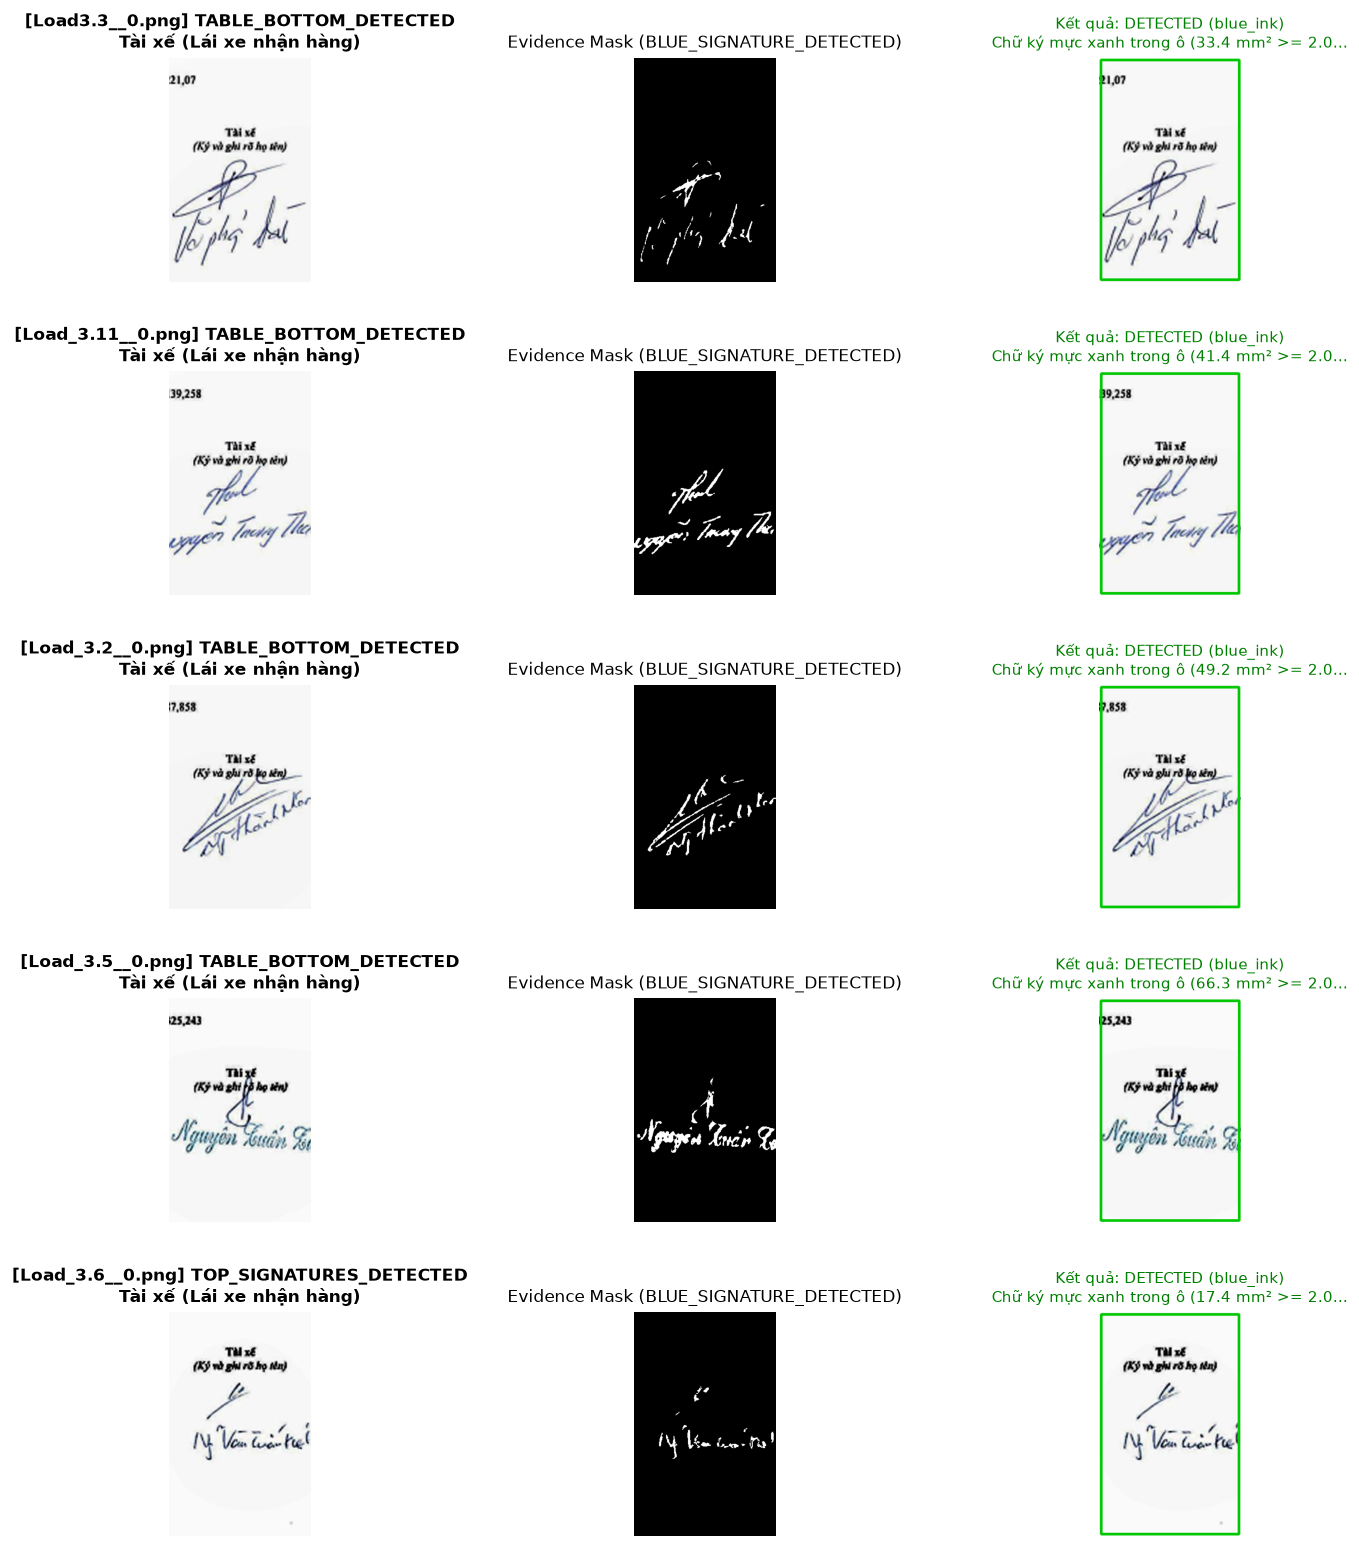

In [6]:
# CELL 5: TRỰC QUAN HÓA CROP INSPECTOR (ROI | MASK | VERDICT) — CHỈ LOADING_PLAN CÓ ZONE
# Chọn động: mỗi trang LOADING_PLAN có target lấy 1 ô (ưu tiên ô required), tối đa 5 trang.
# Không hardcode tên file (bảng cũ toàn ảnh HOA_DON — nay HOÃN).
case_study = []
for r in results_list:
    if r["doc_type"] in _IN_SCOPE_DOC_TYPES and r["targets"]:
        t_pick = next((t for t in r["targets"] if t.get("required", True)), r["targets"][0])
        case_study.append((r, t_pick))
    if len(case_study) >= 5:
        break

if not case_study:
    print("ℹ️  Không có trang LOADING_PLAN nào có zone hợp lệ để trực quan hóa.")
else:
    fig, axes = plt.subplots(len(case_study), 3, figsize=(14, 3.2 * len(case_study)), squeeze=False)
    plt.subplots_adjust(hspace=0.4, wspace=0.25)
    for row, (r, t) in enumerate(case_study):
        fn = r["file_name"]
        raw = cv2.imread(get_image_path(fn))
        scale = 2200.0 / raw.shape[0]
        a4 = cv2.resize(raw, (int(raw.shape[1] * scale), 2200))
        margin = STAMP_MARGIN if t.get("stamp_class") else SIG_MARGIN
        crop, bbox = extract_safe_roi(a4, t["box_norm"], margin)
        if crop is None:
            crop = np.full((60, 60, 3), 255, dtype=np.uint8)

        ax = axes[row, 0]
        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.set_title(f"[{fn}] {r['zone_status']}" + chr(10) + f"{t['role']}", fontsize=10, fontweight="bold")
        ax.axis("off")

        ax = axes[row, 1]
        mask = t.get("mask")
        ax.imshow(mask if mask is not None else np.zeros((100, 100), dtype=np.uint8), cmap="gray")
        ax.set_title(f"Evidence Mask ({t.get('evidence', 'N/A')})", fontsize=10)
        ax.axis("off")

        ax = axes[row, 2]
        vis = crop.copy()
        color_box = (0, 200, 0) if t["detected"] else (0, 0, 220)
        cv2.rectangle(vis, (4, 4), (vis.shape[1] - 4, vis.shape[0] - 4), color_box, 3)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        status_text = "DETECTED" if t["detected"] else "NOT DETECTED"
        ax.set_title(f"Kết quả: {status_text} ({t.get('ink_type')})" + chr(10) + f"{str(t.get('reason'))[:40]}...",
                     fontsize=9, color="green" if t["detected"] else "red")
        ax.axis("off")
    plt.show()
    print(f"✅ Đã render Visual Crop Inspector cho {len(case_study)} trang LOADING_PLAN.")

In [7]:
# CELL 6: XUẤT PRODUCTION CONTRACT JSON & CSV KẾ TOÁN (SỬA 8)
os.makedirs("output/stage4_out", exist_ok=True)
# [TACH DUONG DAN 27/09] ver2 dung hau to _v2; truoc day ghi de mat manifest v1 (su co 26/09).
OUT_JSON = "output/stage4_out/stage4_verification_manifest_v2.json"
OUT_CSV = "output/stage4_out/stage4_audit_summary_v2.csv"

# 1. Chuẩn bị JSON sạch (cấm serialize numpy array)
clean_docs = []
for r in results_list:
    doc_copy = {
        "file_name": r["file_name"],
        "doc_type": r["doc_type"],
        "system": r["system"],
        "batch_id": r["batch_id"],
        "page_role": r["page_role"],
        "modality": r["modality"],
        "zone_status": r["zone_status"],
        "zone_has_signatures": r.get("zone_has_signatures"),
        "zone_description": r.get("zone_description"),
        "anchor_y": r["anchor_y"],
        "doc_status": r["doc_status"],
        "action": r["action"],
        "reason": r["reason"],
        "required_policy": r.get("required_policy"),
        "required_targets": r["required_targets"],
        "detected_required_targets": r["detected_required_targets"],
        "targets": []
    }
    for t in r["targets"]:
        t_clean = {
            "role": t["role"],
            "stamp_class": t["stamp_class"],
            "expected_color": t["expected_color"],
            "required": t["required"],
            "required_original": t.get("required_original"),
            "required_source": t.get("required_source"),
            "policy_channel": t.get("policy_channel"),
            "policy_channel_unresolved": t.get("policy_channel_unresolved"),
            "box_norm": [round(float(v), 4) for v in t["box_norm"]],
            "bbox_px": [int(v) for v in t["bbox_px"]],
            "detected": bool(t["detected"]),
            "confidence": float(t["confidence"]),
            "ink_type": str(t["ink_type"]),
            "reason": str(t["reason"]),
            "evidence": str(t.get("evidence", "")),
            "review_required": bool(t.get("review_required", False)),
            # Ký online: họ tên hệ thống in sẵn (None nếu ô không đi qua nhánh này)
            "e_signature_name": t.get("e_signature_name"),
            # chẩn đoán gọn engine chữ ký Giai đoạn 4 (None nếu không áp dụng, vd. ô mộc / ảnh BW)
            "blue_own_mm2": (None if t.get("blue_own_mm2") is None else float(t["blue_own_mm2"])),
            "blue_edge_mm2": (None if t.get("blue_edge_mm2") is None else float(t["blue_edge_mm2"])),
            "px_per_mm": (None if t.get("px_per_mm") is None else float(t["px_per_mm"]))
        }
        doc_copy["targets"].append(t_clean)
    clean_docs.append(doc_copy)

manifest_data = {
    "version": "2.0.0-stamp-geometry",
    "scope": list(_IN_SCOPE_DOC_TYPES),
    # FIX-A — tính động từ results_list (trước đây hardcode 40/32)
    "n_documents_total": len(clean_docs),
    "n_documents_in_scope": n_in_scope,
    "n_documents_abstain": n_abstain,
    "n_documents_in_scope_by_type": scope_breakdown,
    "n_documents_in_scope_abstain": n_abstain_in_scope,
    "summary": summary_counts,
    "action_summary": action_counts,
    "deferred_doc_types": {"HOA_DON": "HOÃN — cần template Tầng 3b theo từng chi nhánh/kênh"},
    "stage3b_resolver": {"path": STAGE3B_RESOLVER_PATH, "mtime": STAGE3B_RESOLVER_MTIME},
    "image_contract": "Tầng 1 output resize H=2200",
    # Ghi từ CHECK cảnh báo ở Cell 4 — không che giấu giới hạn đã biết.
    "known_issues": known_issues,
    # Giai đoạn 5 — chính sách required theo kênh (nguồn SOP) + phán quyết hồ sơ đa trang (nhóm Tầng 3).
    "required_policy": {"path": os.path.relpath(LP_POLICY["_path"]).replace(os.sep, "/"),
                        "version": LP_POLICY.get("version"),
                        "sop_source": LP_POLICY.get("sop_source"),
                        "pages_channel_unresolved": [r["file_name"] for r in results_list
                                                     if (r.get("required_policy") or {}).get("policy_channel_unresolved")
                                                     and r["doc_type"] in _IN_SCOPE_DOC_TYPES]},
    "dossier_verdicts": dossier_result,
    "documents": clean_docs
}

with open(OUT_JSON, "w", encoding="utf-8") as f:
    json.dump(manifest_data, f, ensure_ascii=False, indent=2)

# 2. Xuất CSV Kế toán kiểm toán
csv_rows = []
for r in results_list:
    if not r["targets"]:
        csv_rows.append({
            "file_name": r["file_name"],
            "doc_type": r["doc_type"],
            "system": r["system"],
            "batch_id": r["batch_id"],
            "doc_status": r["doc_status"],
            "action": r["action"],
            "target_role": "N/A",
            "stamp_class": "N/A",
            "required": False,
            "detected": False,
            "confidence": 0.0,
            "ink_type": "none",
            "reason": r["reason"],
            "review_required": False,
            "abstain": (r["action"] == "ABSTAIN")
        })
    else:
        for t in r["targets"]:
            csv_rows.append({
                "file_name": r["file_name"],
                "doc_type": r["doc_type"],
                "system": r["system"],
                "batch_id": r["batch_id"],
                "doc_status": r["doc_status"],
                "action": r["action"],
                "target_role": t["role"],
                "stamp_class": t["stamp_class"],
                "required": t["required"],
                "detected": t["detected"],
                "confidence": t["confidence"],
                "ink_type": t["ink_type"],
                "reason": t["reason"],
                "review_required": bool(t.get("review_required", False)),
            # Ký online: họ tên hệ thống in sẵn (None nếu ô không đi qua nhánh này)
            "e_signature_name": t.get("e_signature_name"),
                "abstain": False
            })

df_csv = pd.DataFrame(csv_rows)
df_csv.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

print(f"✅ Đã xuất thành công Production Artifacts:")
print(f"   - Manifest JSON : {OUT_JSON} ({len(clean_docs)} tài liệu)")
print(f"   - CSV Kiểm Toán : {OUT_CSV} ({len(df_csv)} bản ghi chi tiết)")

✅ Đã xuất thành công Production Artifacts:
   - Manifest JSON : output/stage4_out/stage4_verification_manifest_v2.json (72 tài liệu)
   - CSV Kiểm Toán : output/stage4_out/stage4_audit_summary_v2.csv (128 bản ghi chi tiết)
